In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

In [3]:
PROJECT_ROOT = Path.cwd().parent

PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"

print("Processed data directory:")
print(PROCESSED_DATA_DIR)

Processed data directory:
e:\PROJECT\ICerdas\09ProjectData\data\processed


In [4]:
processed_files = list(PROCESSED_DATA_DIR.glob("*.csv"))

for file in processed_files:
    print(file.name)

photovoltaic_spring_2022_2023_processed.csv


In [5]:
file_path = PROCESSED_DATA_DIR / "photovoltaic_spring_2022_2023_processed.csv"

df = pd.read_csv(file_path)

print(f"Dataset shape: {df.shape}")

df.head()

Dataset shape: (22461, 13)


,timestamp,Wind_Speed,Weather_Temperature_Celsius,Global_Horizontal_Radiation,Wind_Direction,Weather_Daily_Rainfall,Max_Wind_Speed,Air_Pressure,time_sin,time_cos,day_of_year,month,Active_Power
0,2022-12-01 00:00:00,1.460000,24.023333,-4.278072,137.133331,0.0,2.9,953.200012,0.000000,1.000000,335,12,-0.360147
1,2022-12-01 00:05:00,1.780000,24.010000,-4.020769,133.866669,0.0,3.4,953.196655,0.021815,0.999762,335,12,-0.362342
2,2022-12-01 00:10:00,1.733333,23.903334,-4.154151,140.866669,0.0,2.7,953.116638,0.043619,0.999048,335,12,-0.361312
3,2022-12-01 00:15:00,1.960000,23.656668,-4.593071,135.233337,0.0,3.8,953.099976,0.065403,0.997859,335,12,-0.362036
4,2022-12-01 00:20:00,1.423333,23.520000,-4.745439,133.500000,0.0,2.7,953.073303,0.087156,0.996195,335,12,-0.361138


In [6]:
print("Data types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isna().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("Start timestamp:", df["timestamp"].min())
print("End timestamp:", df["timestamp"].max())

Data types:
timestamp                       object
Wind_Speed                     float64
Weather_Temperature_Celsius    float64
Global_Horizontal_Radiation    float64
Wind_Direction                 float64
Weather_Daily_Rainfall         float64
Max_Wind_Speed                 float64
Air_Pressure                   float64
time_sin                       float64
time_cos                       float64
day_of_year                      int64
month                            int64
Active_Power                   float64
dtype: object

Missing values:
timestamp                      0
Wind_Speed                     0
Weather_Temperature_Celsius    0
Global_Horizontal_Radiation    0
Wind_Direction                 0
Weather_Daily_Rainfall         0
Max_Wind_Speed                 0
Air_Pressure                   0
time_sin                       0
time_cos                       0
day_of_year                    0
month                          0
Active_Power                   0
dtype: int64

Duplica

In [7]:
print("\nActive_Power statistics:")
print(df["Active_Power"].describe())

print("Chronologically sorted:", df["timestamp"].is_monotonic_increasing)


Active_Power statistics:
count    22461.000000
mean       341.412814
std        420.339736
min         -0.478085
25%         -0.366490
50%         58.503207
75%        734.375818
max       1431.940388
Name: Active_Power, dtype: float64
Chronologically sorted: True


In [8]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

FEATURES = [
    "Wind_Speed",
    "Weather_Temperature_Celsius",
    "Global_Horizontal_Radiation",
    "Wind_Direction",
    "Weather_Daily_Rainfall",
    "Max_Wind_Speed",
    "Air_Pressure",
    "time_sin",
    "time_cos",
    "day_of_year",
    "month",
]

TARGET = "Active_Power"

X = df[FEATURES]
y = df[TARGET]

print("Features:")
print(X.columns.tolist())

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Features:
['Wind_Speed', 'Weather_Temperature_Celsius', 'Global_Horizontal_Radiation', 'Wind_Direction', 'Weather_Daily_Rainfall', 'Max_Wind_Speed', 'Air_Pressure', 'time_sin', 'time_cos', 'day_of_year', 'month']

X shape: (22461, 11)
y shape: (22461,)


In [9]:
# 80% data awal untuk training dan 20% data terakhir untuk testing
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training set:", X_train.shape)
print("Testing set :", X_test.shape)

print("Train period:")
print(df["timestamp"].iloc[0])
print("→", df["timestamp"].iloc[split_index - 1])

print("\nTest period:")
print(df["timestamp"].iloc[split_index])
print("→", df["timestamp"].iloc[-1])

Training set: (17968, 11)
Testing set : (4493, 11)
Train period:
2022-12-01 00:00:00
→ 2023-02-12 09:30:00

Test period:
2023-02-12 09:35:00
→ 2023-02-28 23:55:00


In [10]:
# Build Random Forest baseline
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model

RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)

In [11]:
rf_model.fit(X_train, y_train)

print("Random Forest training completed.")


Random Forest training completed.


In [12]:
# Prediction
y_pred = rf_model.predict(X_test)

print("Prediction completed.")
print("Number of predictions:", len(y_pred))

comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

Prediction completed.
Number of predictions: 4493


,Actual,Predicted
0,889.132936,880.935952
1,921.804260,895.461410
2,947.967674,901.158912
3,971.944129,907.095200
4,994.056850,957.513082
5,1013.221632,957.243833
6,1034.599954,972.803397
7,1051.566967,979.294880
8,907.063366,976.463526
9,905.925857,1001.763229


In [13]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Random Forest Baseline Performance")
print("-----------------------------------")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

Random Forest Baseline Performance
-----------------------------------
MAE  : 41.2227
MSE  : 7097.4692
RMSE : 84.2465
R²   : 0.9628


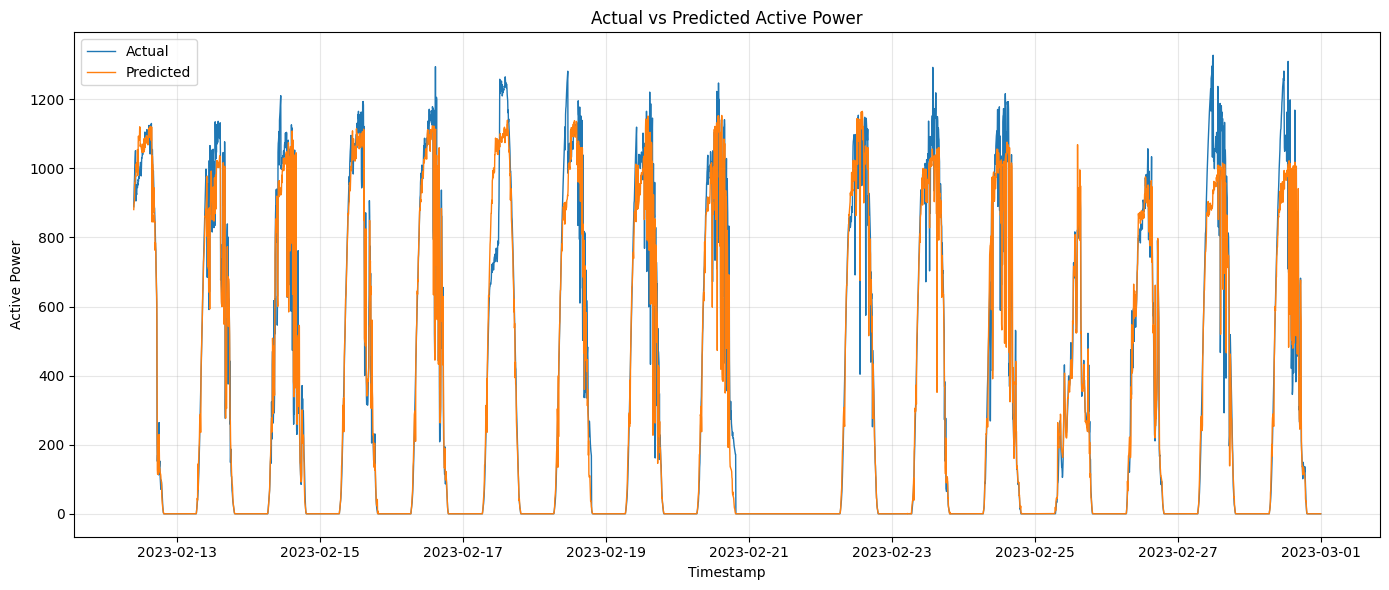

In [14]:
# Actual vs Predicted
plt.figure(figsize=(14, 6))

plt.plot(
    df["timestamp"].iloc[split_index:],
    y_test.values,
    label="Actual",
    linewidth=1
)

plt.plot(
    df["timestamp"].iloc[split_index:],
    y_pred,
    label="Predicted",
    linewidth=1
)

plt.title("Actual vs Predicted Active Power")
plt.xlabel("Timestamp")
plt.ylabel("Active Power")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

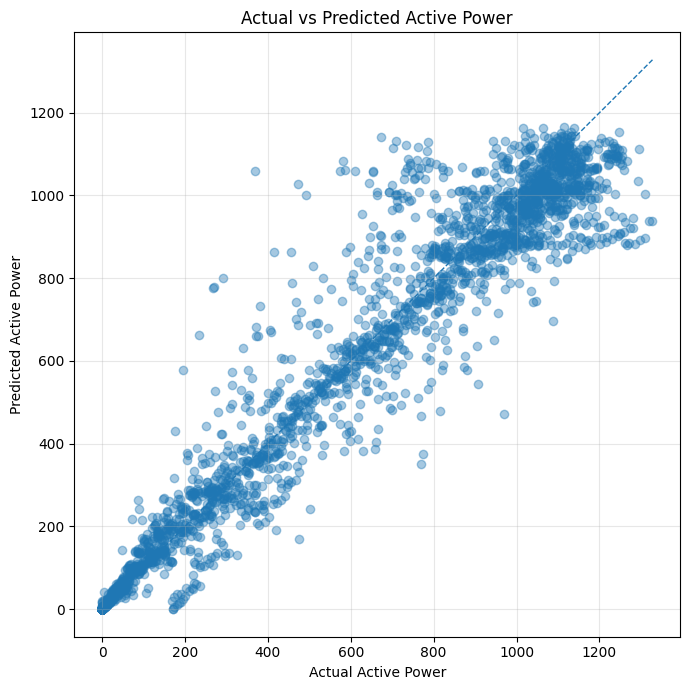

In [15]:
# Scatter Actual vs Predicted
plt.figure(figsize=(7, 7))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.4
)

min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    linewidth=1
)

plt.title("Actual vs Predicted Active Power")
plt.xlabel("Actual Active Power")
plt.ylabel("Predicted Active Power")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:
# Residual 
residuals = y_test.values - y_pred

residual_df = pd.DataFrame({
    "timestamp": df["timestamp"].iloc[split_index:].values,
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Residual": residuals
})

residual_df.head()

print("Residual statistics:")
print(residual_df["Residual"].describe())

Residual statistics:
count    4493.000000
mean        9.465844
std        83.722321
min      -692.052013
25%        -0.074009
50%        -0.000772
75%        17.618856
max       495.796745
Name: Residual, dtype: float64


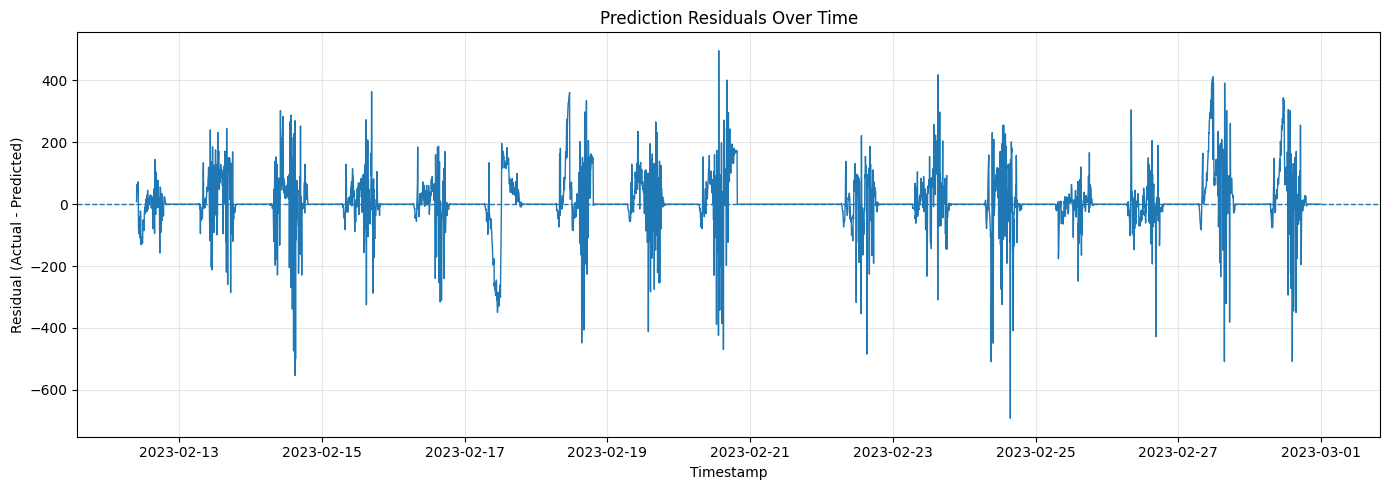

In [17]:
plt.figure(figsize=(14, 5))

plt.plot(
    residual_df["timestamp"],
    residual_df["Residual"],
    linewidth=1
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.title("Prediction Residuals Over Time")
plt.xlabel("Timestamp")
plt.ylabel("Residual (Actual - Predicted)")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
# Error
residual_df["Absolute_Error"] = np.abs(residual_df["Residual"])

residual_df["Power_Range"] = pd.cut(
    residual_df["Actual"],
    bins=[-np.inf, 0, 100, 500, 1000, np.inf],
    labels=[
        "≤ 0",
        "0–100",
        "100–500",
        "500–1000",
        "> 1000"
    ]
)

error_by_range = (
    residual_df
    .groupby("Power_Range", observed=False)
    .agg(
        Count=("Absolute_Error", "count"),
        MAE=("Absolute_Error", "mean")
    )
    .reset_index()
)

error_by_range

,Power_Range,Count,MAE
0,≤ 0,2082,0.065482
1,0–100,285,13.888037
2,100–500,618,68.087219
3,500–1000,825,88.917113
4,> 1000,683,96.171105


In [19]:
# Random Forest Feature Importance
feature_importance = pd.DataFrame({
    "Feature": FEATURES,
    "Importance": rf_model.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

feature_importance

,Feature,Importance
0,Global_Horizontal_Radiation,0.929333
1,time_cos,0.021536
2,day_of_year,0.016614
3,Weather_Temperature_Celsius,0.011217
4,time_sin,0.006773
5,Air_Pressure,0.006359
6,Wind_Direction,0.003737
7,Wind_Speed,0.002089
8,Max_Wind_Speed,0.001778
9,month,0.000519


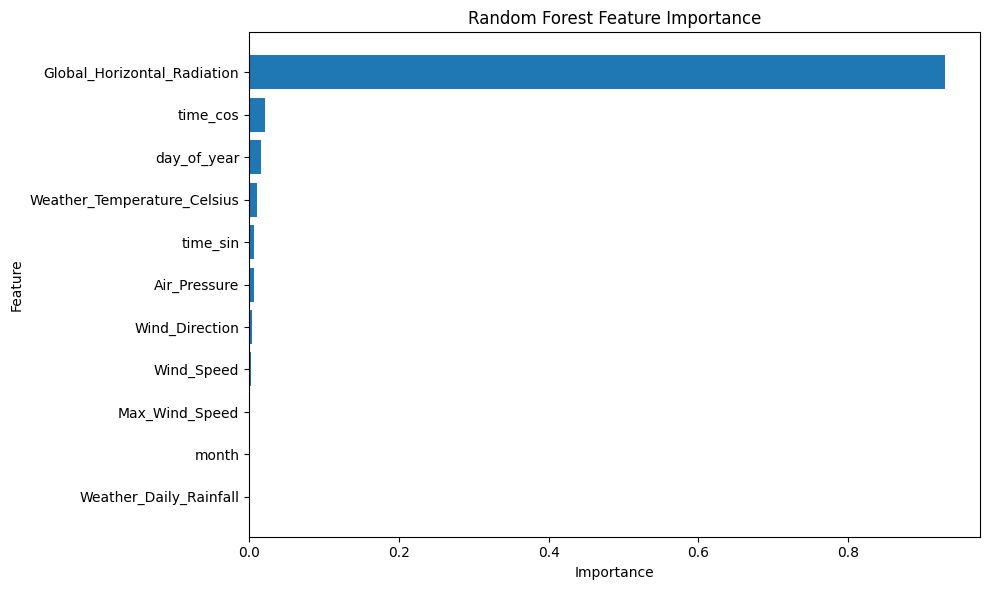

In [20]:
# Feature Importance Plot
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [21]:
# Permutation Importance
from sklearn.inspection import permutation_importance

perm_importance = permutation_importance(
    rf_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="r2",
    n_jobs=-1
)

perm_importance_df = pd.DataFrame({
    "Feature": FEATURES,
    "Importance_Mean": perm_importance.importances_mean,
    "Importance_Std": perm_importance.importances_std
})

perm_importance_df = (
    perm_importance_df
    .sort_values("Importance_Mean", ascending=False)
    .reset_index(drop=True)
)

perm_importance_df

,Feature,Importance_Mean,Importance_Std
0,Global_Horizontal_Radiation,1.261873,0.023235
1,time_cos,0.118881,0.006247
2,time_sin,0.010266,0.001482
3,Weather_Temperature_Celsius,0.009386,0.000741
4,Max_Wind_Speed,0.000317,0.000099
5,Weather_Daily_Rainfall,0.000004,0.000005
6,day_of_year,0.000000,0.000000
7,month,0.000000,0.000000
8,Wind_Speed,-0.000211,0.000117
9,Wind_Direction,-0.000236,0.000098


In [22]:
TOP_4_FEATURES = [
    "Global_Horizontal_Radiation",
    "time_cos",
    "time_sin",
    "Weather_Temperature_Celsius",
]

TOP_2_FEATURES = [
    "Global_Horizontal_Radiation",
    "time_cos",
]

print("All features:", len(FEATURES))
print("Top 4 features:", TOP_4_FEATURES)
print("Top 2 features:", TOP_2_FEATURES)

All features: 11
Top 4 features: ['Global_Horizontal_Radiation', 'time_cos', 'time_sin', 'Weather_Temperature_Celsius']
Top 2 features: ['Global_Horizontal_Radiation', 'time_cos']


In [23]:
# Train reduced-feature models
X_train_top4 = X_train[TOP_4_FEATURES]
X_test_top4 = X_test[TOP_4_FEATURES]

X_train_top2 = X_train[TOP_2_FEATURES]
X_test_top2 = X_test[TOP_2_FEATURES]

rf_top4 = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_top2 = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_top4.fit(X_train_top4, y_train)
rf_top2.fit(X_train_top2, y_train)

RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)

In [24]:
# Evaluation
y_pred_top4 = rf_top4.predict(X_test_top4)
y_pred_top2 = rf_top2.predict(X_test_top2)

results = []

for model_name, y_prediction in [
    ("RF - All 11 Features", y_pred),
    ("RF - Top 4 Features", y_pred_top4),
    ("RF - Top 2 Features", y_pred_top2),
]:
    mae = mean_absolute_error(y_test, y_prediction)
    mse = mean_squared_error(y_test, y_prediction)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_prediction)

    results.append({
        "Model": model_name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2,
    })

comparison_results = pd.DataFrame(results)

comparison_results

,Model,MAE,MSE,RMSE,R2
0,RF - All 11 Features,41.222748,7097.469235,84.246479,0.962788
1,RF - Top 4 Features,48.149182,8468.204123,92.022846,0.955601
2,RF - Top 2 Features,60.838748,12375.918157,111.247104,0.935112


In [25]:
# Time Series Cross Validation
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV

tscv = TimeSeriesSplit(n_splits=5)

print("Number of CV splits:", tscv.get_n_splits())

Number of CV splits: 5


In [26]:
param_distributions = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": [1.0, "sqrt", "log2"],
}

In [27]:
rf_tuning = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

In [28]:
random_search = RandomizedSearchCV(
    estimator=rf_tuning,
    param_distributions=param_distributions,
    n_iter=15,
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 15 candidates, totalling 75 fits


RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
                   estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
                   n_iter=15, n_jobs=-1,
                   param_distributions={'max_depth': [None, 10, 20, 30],
                                        'max_features': [1.0, 'sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300, 500]},
                   random_state=42, scoring='neg_root_mean_squared_error',
                   verbose=1)

In [29]:
print("Best parameters:")
print(random_search.best_params_)

print("\nBest CV RMSE:")
print(-random_search.best_score_)

Best parameters:
{'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 10}

Best CV RMSE:
104.91554539948774


In [30]:
best_rf = random_search.best_estimator_
y_pred_tuned = best_rf.predict(X_test)

mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
mse_tuned = mean_squared_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mse_tuned)
r2_tuned = r2_score(y_test, y_pred_tuned)

print("Tuned Random Forest Performance")
print("--------------------------------")
print(f"MAE  : {mae_tuned:.4f}")
print(f"MSE  : {mse_tuned:.4f}")
print(f"RMSE : {rmse_tuned:.4f}")
print(f"R²   : {r2_tuned:.4f}")

Tuned Random Forest Performance
--------------------------------
MAE  : 43.0992
MSE  : 6535.9868
RMSE : 80.8455
R²   : 0.9657
